# Regolith Dielectric Map — S1 Week 2

Lunar regolith dielectric properties and their effect on a communication link.

This notebook covers:
1. Loss tangent vs frequency for three regolith densities
2. Permittivity / loss tangent / skin depth summary across bands
3. Key number: how much the tan d = 0 (Edwards 2023) assumption underestimates loss at S-band
4. South Pole DEM context (Connecting Ridge, Shackleton rim)

Models implemented in `lunarcomms.regolith.dielectric`:
- Permittivity: eps' = 1.919^rho  (Olhoeft & Strangway 1975)
- Loss tangent: tan d = 10^(0.312 rho - 2.636) * f_GHz^0.278  (Siegler et al. 2020)
- Skin depth: delta_s = lambda0 / (pi * sqrt(eps') * tan d)  (Ulaby & Long 2014)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from lunarcomms.regolith.dielectric import (
    permittivity, loss_tangent, complex_permittivity, skin_depth_m
)

%matplotlib inline


## 1. Loss tangent vs frequency (three densities)

The required deliverable: tan d versus frequency for three representative regolith densities, with the UHF / S / Ka bands marked.

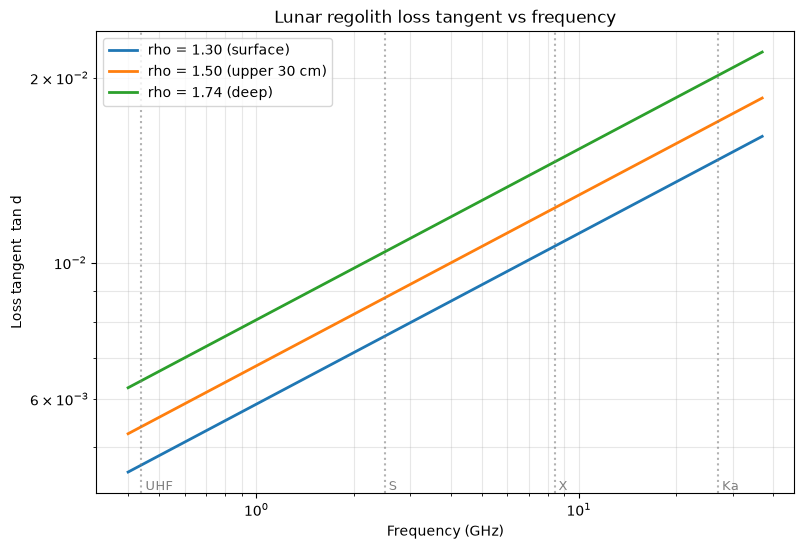

In [2]:
freqs = np.logspace(np.log10(0.4), np.log10(37), 300)   # GHz
densities = [1.30, 1.50, 1.74]                          # surface / upper / deep regolith
labels = ["rho = 1.30 (surface)", "rho = 1.50 (upper 30 cm)", "rho = 1.74 (deep)"]

fig, ax = plt.subplots(figsize=(9, 6))
for rho, lab in zip(densities, labels):
    ax.loglog(freqs, loss_tangent(rho, freqs), lw=2, label=lab)

for fb, name in [(0.44, "UHF"), (2.5, "S"), (8.4, "X"), (27.0, "Ka")]:
    ax.axvline(fb, color="grey", ls=":", alpha=0.6)
    ax.text(fb, ax.get_ylim()[0], " " + name, color="grey", va="bottom", fontsize=9)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Loss tangent  tan d")
ax.set_title("Lunar regolith loss tangent vs frequency")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


Loss tangent rises with both **frequency** (the f^0.278 power law, from ilmenite dissipation) and **density** (the 0.312*rho term). Higher bands and denser regolith are lossier.

## 2. Permittivity, loss tangent, and skin depth across bands

At the nominal upper-layer density rho = 1.50 g/cm^3.

In [3]:
rho = 1.50
print(f"{'Band':<6}{'f (GHz)':>9}{'eps_prime':>12}{'tan d':>12}{'skin depth (m)':>16}")
print("-" * 55)
for name, f in [("UHF", 0.44), ("S", 2.5), ("X", 8.4), ("Ka", 27.0)]:
    print(f"{name:<6}{f:>9.2f}{permittivity(rho):>12.3f}"
          f"{loss_tangent(rho, f):>12.5f}{skin_depth_m(rho, f):>16.3f}")


Band    f (GHz)   eps_prime       tan d  skin depth (m)
-------------------------------------------------------
UHF        0.44       2.658     0.00541          24.605
S          2.50       2.658     0.00876           2.672
X          8.40       2.658     0.01227           0.568
Ka        27.00       2.658     0.01698           0.128


Skin depth shrinks sharply with frequency: metres at UHF/S-band, centimetres by Ka-band. This is why low frequencies are used for subsurface sounding and high frequencies are surface-only.

## 3. Key number: the tan d = 0 assumption at S-band

Edwards et al. (2023) use tan d = 0 (lossless). The dielectric absorption over a path L is

    Loss_dB = 8.686 * L / delta_s

(one skin depth = 1 neper of field = 8.686 dB of power). Computed for rho = 1.50, f = 2.5 GHz.


In [4]:
rho, f, L = 1.50, 2.5, 10_000.0  # 10 km path, in metres
ds = skin_depth_m(rho, f)
loss_per_m = 8.686 / ds
loss_total = 8.686 * L / ds

print(f"skin depth          : {ds:.3f} m")
print(f"dielectric loss rate: {loss_per_m:.3f} dB/m")
print(f"loss over 10 km     : {loss_total:,.0f} dB  (with real tan d)")
print(f"loss with tan d = 0 : 0 dB  (Edwards 2023)")
print(f"--> underestimate   : {loss_total:,.0f} dB over 10 km")


skin depth          : 2.672 m
dielectric loss rate: 3.251 dB/m
loss over 10 km     : 32,510 dB  (with real tan d)
loss with tan d = 0 : 0 dB  (Edwards 2023)
--> underestimate   : 32,510 dB over 10 km


**Interpretation.** The skin depth at S-band is only ~2.7 m, so the dielectric loss rate is ~3.25 dB/m. Lunar regolith blocks S-band within a few metres.

- For a **vacuum surface link** (signal travels above the regolith), the tan d = 0 assumption is fine — the wave barely interacts with the medium.
- For any **subsurface or grazing path through regolith**, ignoring tan d is severe: even a few metres of regolith costs ~10 dB that Edwards (2023) omits.

The 10 km figure is illustrative — you would never propagate that far *through* regolith at S-band; the meaningful quantity is the **per-metre rate (~3.25 dB/m)** equivalently stated as the **2.7 m skin depth**.

*Note: the loss_tangent docstring's "~0.3-0.6 dB/km" hint corresponds to a different (mostly-vacuum) scenario, not the skin-depth-through-medium calculation here.*


## 4. South Pole DEM context

The two scenario sites from PGDA-78 (LRO/LOLA, 5 m/pixel): Connecting Ridge (Site01) and Shackleton rim (Site04).

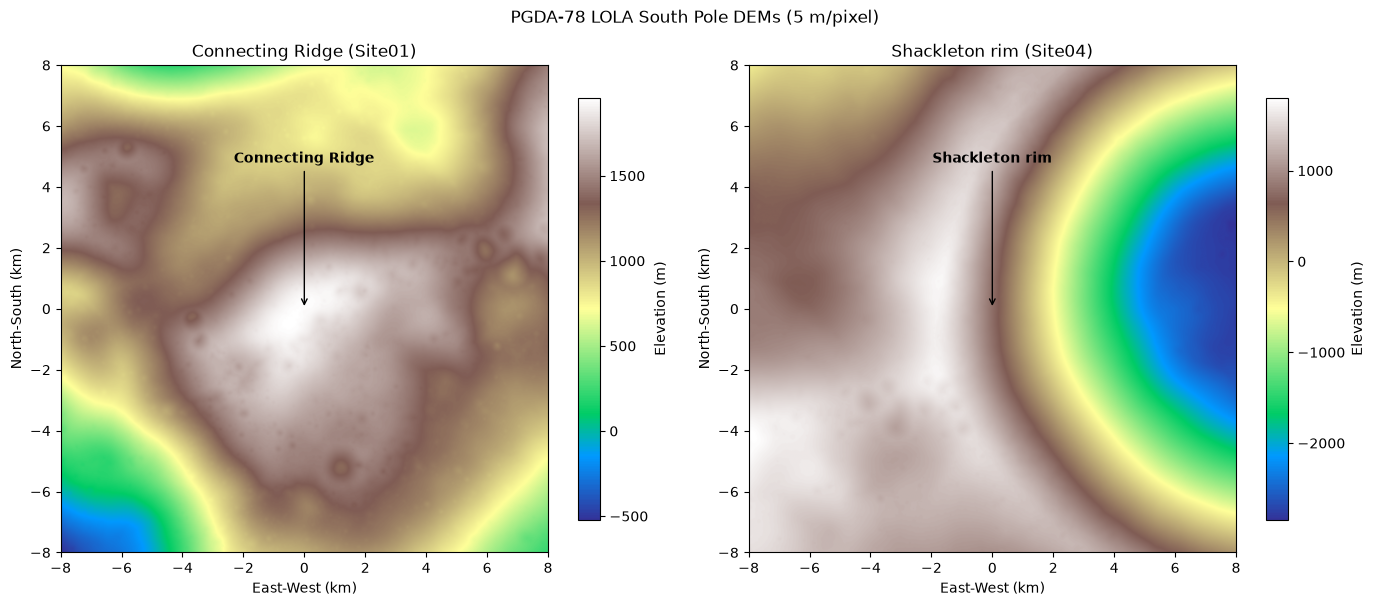

In [5]:
from lunarcomms.io.pgda import load_dem

def find_dem(site):
    for base in [Path("data/dem"), Path("../data/dem")]:
        p = base / site / f"{site}_final_adj_5mpp_surf.tif"
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"DEM for {site} not found - run data/download_pgda.py")

sites = [("Site01", "Connecting Ridge"), ("Site04", "Shackleton rim")]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (site, label) in zip(axes, sites):
    data, transform, crs = load_dem(find_dem(site))
    half_km = (data.shape[0] * abs(transform.a)) / 1000.0 / 2.0
    extent = [-half_km, half_km, -half_km, half_km]
    im = ax.imshow(data, cmap="terrain", extent=extent, origin="upper")
    ax.set_title(f"{label} ({site})")
    ax.set_xlabel("East-West (km)")
    ax.set_ylabel("North-South (km)")
    ax.annotate(label, xy=(0, 0), xytext=(0, half_km * 0.6), ha="center",
                fontsize=10, fontweight="bold",
                arrowprops=dict(arrowstyle="->"))
    fig.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
fig.suptitle("PGDA-78 LOLA South Pole DEMs (5 m/pixel)")
fig.tight_layout()
plt.show()


## Summary

- Loss tangent and skin depth depend strongly on frequency and density.
- At S-band, regolith skin depth ~2.7 m (loss ~3.25 dB/m); the tan d = 0 assumption is only valid for vacuum surface links.
- The DEM sites provide the terrain context for the reflection/multipath geometry studied in later weeks.
